In [4]:
!pip install gensim Sastrawi scikit-learn pandas matplotlib seaborn

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   -- ------------------------------------- 1.3/24.4 MB 3.5 MB/s eta 0:00:07
   --- ------------------------------------ 1.8/24.4 MB 3.5 MB/s eta 0:00:07
   ---- ----------------------------------- 2.9/24.4 MB 3.7 MB/s eta 0:00:06
   ------ --------------------------------- 3.9/24.4 MB 4.0 MB/s eta 0:00:06
   -------- ------------------------------- 5.0/24.4 MB 4.3 MB/s eta 0:00:05
   --------- ------------------------------ 5.8/24.4 MB 4.4 MB/s eta 0:00:05
   ---------- ----------------------------- 6.3/24.4 MB 3.8 MB/s eta 0:00:05
   ----------- ---------------------------- 6.8/24.4 MB 3.7 MB/s eta 0:00:05
   ----------- ---------------------------- 7.1/24.4 MB 3.4 MB/s eta 0:00:06
   ------------ --------------------------- 7.9/24.4 MB 3.5 MB/s eta 0:00:05
   ------------- ---

In [5]:
import pandas as pd
import numpy as np
import re

from gensim.models import Word2Vec
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("hasil_scraping_detik.csv")

print("Jumlah data:", len(df))
print("Nama kolom:", df.columns.tolist())

df.head()

Jumlah data: 205
Nama kolom: ['kategori', 'judul', 'url', 'isi']


,kategori,judul,url,isi
0,Finance,"Bitcoin Tembus US$ 87.000, Ini Sederet Pemicunya",https://finance.detik.com/fintech/d-8674812/bi...,Jakarta - Harga Bitcoin (BTC) sempat menembus ...
1,Finance,"Harga Bitcoin Terbang ke Rp 1,53 M, Tertinggi ...",https://finance.detik.com/fintech/d-8673320/ha...,Jakarta - Harga Bitcoin naik menembus level US...
2,Finance,Bitcoin Melesat Usai Pengumuman Suku Bunga AS,https://finance.detik.com/fintech/d-8667716/bi...,Jakarta - Harga Bitcoin (BTC) bergerak naik da...
3,Finance,"Investor Muda Dominasi Pasar Modal, Ajaib Kena...",https://finance.detik.com/fintech/d-8673492/in...,Jakarta - Ajaib memperkuat edukasi pasar modal...
4,Finance,"Harga Bitcoin Naik Jadi 1,35 Miliar Usai The F...",https://finance.detik.com/fintech/d-8666685/ha...,Jakarta - Harga Bitcoin menguat pada perdagang...


In [7]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("indonesian"))

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocessing(teks):
    teks = str(teks).lower()
    teks = re.sub(r"http\S+|www\S+", "", teks)
    teks = re.sub(r"[^a-zA-Z\s]", " ", teks)
    tokens = teks.split()

    tokens = [
        stemmer.stem(kata)
        for kata in tokens
        if kata not in stop_words and len(kata) > 2
    ]

    return tokens

[nltk_data] Downloading package stopwords to C:\Users\Assatya
[nltk_data]     Dewantara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
X = df["isi"].fillna("").astype(str)
y = df["kategori"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", len(X_train))
print("Data testing:", len(X_test))

Data training: 164
Data testing: 41


In [9]:
# Preprocessing data training
token_train = [preprocessing(teks) for teks in X_train]

# Membuat model Word2Vec Skip-Gram
model = Word2Vec(
    sentences=token_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    epochs=20,
    seed=42
)

print("Ukuran vocabulary:", len(model.wv))
print("Dimensi vektor:", model.vector_size)

Ukuran vocabulary: 4026
Dimensi vektor: 100


In [10]:
def vektor_berita(tokens, model):
    vectors = [
        model.wv[kata]
        for kata in tokens
        if kata in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

# Preprocessing data testing
token_test = [preprocessing(teks) for teks in X_test]

# Membentuk vektor berita
X_train_vec = np.array([
    vektor_berita(tokens, model)
    for tokens in token_train
])

X_test_vec = np.array([
    vektor_berita(tokens, model)
    for tokens in token_test
])

print("Bentuk vektor training:", X_train_vec.shape)
print("Bentuk vektor testing:", X_test_vec.shape)

Bentuk vektor training: (164, 100)
Bentuk vektor testing: (41, 100)


In [11]:
# Membuat model Gaussian Naive Bayes
nb_model = GaussianNB()

# Training
nb_model.fit(X_train_vec, y_train)

# Prediksi
y_pred = nb_model.predict(X_test_vec)

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

     Finance       1.00      1.00      1.00        20
       Sport       1.00      1.00      1.00        21

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



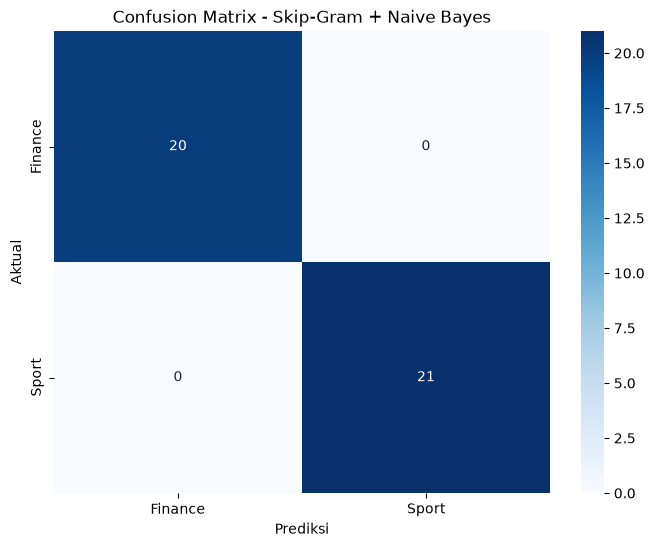

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=nb_model.classes_
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - Skip-Gram + Naive Bayes")
plt.show()

In [14]:
import json
import os

os.makedirs("hasil", exist_ok=True)

# Menyimpan hasil prediksi berita
hasil_klasifikasi = pd.DataFrame({
    "berita": X_test.values,
    "kategori_aktual": y_test.values,
    "kategori_prediksi": y_pred
})

hasil_klasifikasi.to_json(
    "hasil/hasil_klasifikasi.json",
    orient="records",
    force_ascii=False,
    indent=4
)

# Menyimpan evaluasi model
evaluasi = {
    "total_data": int(len(df)),
    "data_training": int(len(X_train)),
    "data_testing": int(len(X_test)),
    "jumlah_kategori": int(y.nunique()),
    "dimensi_vektor": int(model.vector_size),
    "akurasi": float(accuracy),
    "kategori": [str(k) for k in nb_model.classes_],
    "confusion_matrix": cm.tolist(),
    "classification_report": classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )
}

with open("hasil/hasil_evaluasi.json", "w", encoding="utf-8") as file:
    json.dump(evaluasi, file, ensure_ascii=False, indent=4)

print("Hasil berhasil disimpan!")

Hasil berhasil disimpan!
